In [ ]:
import pandas as pd
from pathlib import Path
import preprocessing as pp

StartPath = Path.cwd().parents[0]
data_dir = StartPath / 'data' / 'mediums_dataset'
small_data_dir = StartPath / 'data' / 'small_dataset'
_SMALL_RAW_FILEPATH = small_data_dir / 'news_sample.csv'
_SMALL_PREPROCESSED_FILEPATH = small_data_dir / 'preprocessed_news_sample.csv'
_RAW_FILEPATH = data_dir / '995,000_rows.csv'
_PREPROCESSED_FILEPATH = data_dir / 'preprocessed_dataset.csv'
preprocessed_vocab_path = data_dir / 'preprocessed_vocabulary.csv'
raw_vocab_path = data_dir / 'raw_vocabulary.csv'
preprocessed_vocab_stats_path = data_dir / 'preprocessed_vocabulary_stats.csv'
raw_vocab_stats_path = data_dir / 'raw_vocabulary_stats.csv'
preprocessed_reduced_vocab_stats_path = data_dir / "preprocessed_reduced_vocabulary_stats.csv"
raw_reduced_vocab_stats_path = data_dir / "raw_reduced_vocabulary_stats.csv"
_CHUNKSIZE = 50000

In [63]:
def get_vocab(df):
    return df['content'].str.split().explode(ignore_index=True).unique()
def dataset_vocab_to_csv(filepath, output_path):
    reader =  pd.read_csv(
        filepath,
        chunksize=_CHUNKSIZE,
        quotechar='"',
        usecols=['content'],
        low_memory=False
    )
    vocab = set()
    i = 0
    for i, chunk_vocab in enumerate(map(get_vocab, reader), 1):
        vocab.update(chunk_vocab)
        print(i)
    pd.Series(list(vocab)).to_csv(output_path, mode='w', header=False, index=False)

    print("Vocabulary finished")

def get_vocab_stats_to_csv(content_path, vocab_path, output_path):
    df_dict = {
        word: {'count': 0}
        for word in pd.read_csv(vocab_path, header=None, low_memory=False)[0]
    }

    print('constructed vocab dictionary')

    with pd.read_csv(
        content_path,
        chunksize=_CHUNKSIZE,
        usecols=['content']
    ) as reader:
        i = 0
        for chunk in reader:
            i += 1
            print(i*_CHUNKSIZE)
            chunk_vocab = chunk['content'].str.split(' ').fillna('')
            for tokens in chunk_vocab:
                for token in tokens:
                    df_dict.setdefault(token, {'count': 0})
                    df_dict[token]['count'] += 1

    df = pd.DataFrame({
        'word': [token for token in df_dict.keys()],
        'count': [df_dict[token]['count'] for token in df_dict.keys()]
    })
    df = df.sort_values(by=['count'], ascending=False)
    df.to_csv(output_path,mode="w",header=True, index=False)

def reduce_vocab_stats_to_csv(vocab_stats_path, output_path):
    df = pd.read_csv(vocab_stats_path, low_memory=False)
    df['count'] = df['count'].astype(int)
    df = df.head(10000)

    df.to_csv(output_path,mode="w",header=True, index=False)

In [ ]:
# for news_sample.csv
cleaned_path = small_data_dir / 'cleaned_news_sample.csv'
stopword_rm_path = small_data_dir / 'stopword_rm_news_sample.csv'
stemming_stopword_rm_path = small_data_dir / 'stemming_stopword_rm_news_sample.csv'

cleaned_vocab_path = small_data_dir / 'cleaned_vocab.csv'
stopword_rm_vocab_path = small_data_dir / 'stopword_rm_vocab.csv'
stemming_stopword_rm_vocab_path = small_data_dir / 'stemming_stopword_rm_vocab.csv'

cleaned_vocab_stats_path = small_data_dir / 'cleaned_vocab_stats.csv'
stopword_rm_vocab_stats_path = small_data_dir / 'stopword_rm_vocab_stats.csv'
stemming_stopword_rm_vocab_stats_path = small_data_dir / 'stemming_stopword_rm_vocab_stats.csv'

cleaned_reduced_vocab_stats_path = small_data_dir / 'cleaned_reduced_vocab_stats.csv'
stopword_rm_reduced_vocab_stats_path = small_data_dir / 'stopword_rm_reduced_vocab_stats.csv'
stemming_stopword_rm_reduced_vocab_stats_path = small_data_dir / 'stemming_stopword_rm_reduced_vocab_stats.csv'

df = pd.read_csv(_SMALL_RAW_FILEPATH, usecols=['content'], low_memory=False)
df['content'] = pp.clean_text(df['content'])
df.to_csv(cleaned_path, index=False)

df['content'] = pp.tokens_to_string(pp.rm_stopwords(pp.tokenize_series(df['content'])))
df.to_csv(stopword_rm_path, index=False)

df['content'] = pp.tokens_to_string(pp.stem_tokens(pp.tokenize_series(df['content'])))
df.to_csv(stemming_stopword_rm_path, index=False)


dataset_vocab_to_csv(_RAW_FILEPATH, raw_vocab_path)
dataset_vocab_to_csv(cleaned_path, cleaned_vocab_path)
dataset_vocab_to_csv(stopword_rm_path, stopword_rm_vocab_path)
dataset_vocab_to_csv(stemming_stopword_rm_path, stemming_stopword_rm_vocab_path)

1
Vocabulary finished
1
Vocabulary finished
1
Vocabulary finished
1
Vocabulary finished


In [65]:
raw_vocab = pd.read_csv(raw_vocab_path).to_numpy(dtype=str)
cleaned_vocab = pd.read_csv(cleaned_vocab_path).to_numpy(dtype=str)
stopword_rm_vocab = pd.read_csv(stopword_rm_vocab_path).to_numpy(dtype=str)
stemming_stopword_rm_vocab = pd.read_csv(stemming_stopword_rm_vocab_path).to_numpy(dtype=str)

print(f'Raw vocabulary size: {len(raw_vocab):,}')
print(f'Cleaned vocabulary size: {len(cleaned_vocab):,}')
print(f'Cleaned and stopwords removed vocabulary size: {len(stopword_rm_vocab):,}')
print(f'Cleaned, stopwords removed, and stemming vocabulary size: {len(stemming_stopword_rm_vocab):,}')

Raw vocabulary size: 30,004
Cleaned vocabulary size: 16,373
Cleaned and stopwords removed vocabulary size: 16,244
Cleaned, stopwords removed, and stemming vocabulary size: 10,725


In [66]:
dataset_vocab_to_csv(_PREPROCESSED_FILEPATH, preprocessed_vocab_path)
dataset_vocab_to_csv(_RAW_FILEPATH, raw_vocab_path)

1
Vocabulary finished
1
Vocabulary finished


In [67]:
get_vocab_stats_to_csv(
    _PREPROCESSED_FILEPATH,
    preprocessed_vocab_path,
    preprocessed_vocab_stats_path
)
get_vocab_stats_to_csv(
    _RAW_FILEPATH,
    raw_vocab_path,
    raw_vocab_stats_path
)

constructed vocab dictionary


50000
constructed vocab dictionary
50000


In [68]:
reduce_vocab_stats_to_csv(
    preprocessed_vocab_stats_path,
    preprocessed_reduced_vocab_stats_path
)
reduce_vocab_stats_to_csv(
    raw_vocab_stats_path,
    raw_reduced_vocab_stats_path
)


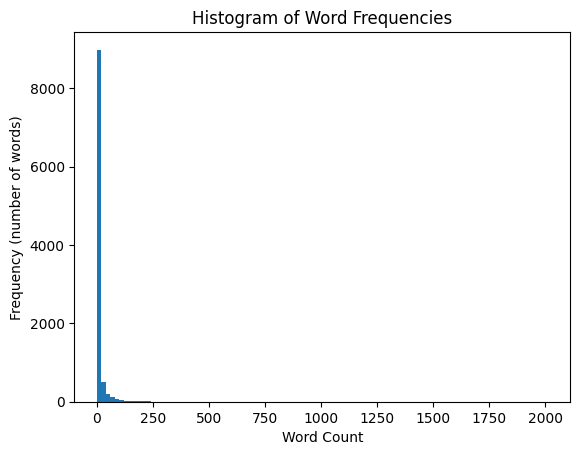

In [69]:
import matplotlib.pyplot as plt

df_preprocessed = pd.read_csv(preprocessed_reduced_vocab_stats_path)

plt.figure()
plt.hist(df_preprocessed["count"], bins=100)
plt.xlabel("Word Count")
plt.ylabel("Frequency (number of words)")
plt.title("Histogram of Word Frequencies")
plt.show()

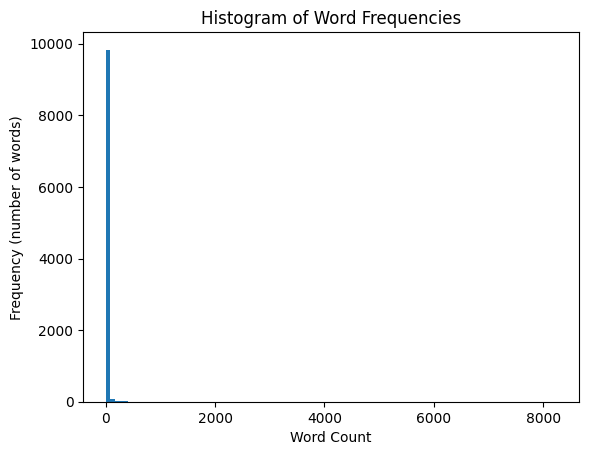

In [70]:
df_raw = pd.read_csv(raw_reduced_vocab_stats_path)

plt.figure()
plt.hist(df_raw["count"], bins=100)
plt.xlabel("Word Count")
plt.ylabel("Frequency (number of words)")
plt.title("Histogram of Word Frequencies")
plt.show()

In [71]:
df = pd.read_csv(preprocessed_vocab_stats_path).set_index('word')
tokens = ['<url>', '<date>', '<num>', '<email>']
for token in tokens:
    print(f'{df.at[token, 'count']:,}')

480
189
2,011
8
